# Economic impact of the aerosol pathway at matched GWL 2.0

Takes the statistical result (RAMIP arms are nearly indistinguishable in monthly `tas` once
matched on global warming — land rejection fractions at the 0.057 false-positive floor) and asks
the question: **does that statistical near-equivalence translate
into an equivalent economic impact?**

Method:

- **Dose-response**: Burke, Hsiang & Miguel (2015) pooled quadratic, annual GDP-per-capita growth
  as a function of annual mean temperature, `g(T) = β₁T + β₂T²` with β₁ = 0.0127,
  β₂ = −0.0005 °C⁻², peaking near 13 °C.
- **Exposure**: annual-mean surface temperature per pixel, over each arm's own GWL2.0 decade
  (windows from `ks_path_independence_ramip_gwl.ipynb`).
- **Impact**: Δg = g(T_126aer) − g(T_ssp370) per pixel per run — the growth-rate difference
  attributable to taking the aerosol-cleanup pathway to the *same* global warming level.

**What this deliberately is not.** Burke's coefficients were estimated on country-level annual
data; applying them per pixel is the standard-but-crude downscaling the impacts literature itself
flags. There is no population weighting (no gridded population product in this repo), no
bias correction, and no reanalysis-uncertainty sampling, so the numbers here are read as
**differences between arms**, where the dose-response error largely cancels, not as damage levels.
Mortality (Carleton) and payroll (Behrer) need daily data and are out of reach with the monthly
RAMIP archive.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import regionmask

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt

dir_list = get_params()
warnings.filterwarnings('ignore', category=FutureWarning)

RAMIP   = dir_list['raw'] + 'ramip/'
GWL_DIR = dir_list['aux'] + 'diagnostics/ramip_gwl/'
IMP_DIR = dir_list['aux'] + 'diagnostics/impacts/'
os.makedirs(IMP_DIR, exist_ok=True)
out_dir = dir_list['aux'] + '../figures/'

GWL   = 2.0
WIN   = kt.WIN
OTHER = 'ssp370-126aer'
ANCHOR = {m: 'ssp370' for m in os.listdir(RAMIP)}
ANCHOR['CESM2'] = 'ssp370-LE'

# Burke, Hsiang & Miguel (2015), pooled specification, no lags
B1, B2 = 0.0127, -0.0005


def burke_growth(t_c):
    """annual GDP-per-capita growth response to annual mean temperature in degC"""
    return B1 * t_c + B2 * t_c ** 2


win_df = pd.read_csv(f'{GWL_DIR}gwl{GWL}_windows.csv')
USABLE = {m: win_df[(win_df.model == m) & win_df.usable] for m in sorted(ANCHOR)}
MODELS = [m for m in sorted(ANCHOR) if len(USABLE[m])]
print('models:', MODELS)
print(f'Burke optimum at {-B1 / (2 * B2):.1f} degC')

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


models: ['CESM2', 'CNRM-ESM2-1', 'CanESM5-1', 'EC-Earth3-AerChem', 'GISS-E2-1-G', 'MIROC6', 'MRI-ESM2-0', 'UKESM1-0-LL']
Burke optimum at 12.7 degC


## Annual-mean exposure and the growth response

For each run and arm: monthly `tas` over the arm's GWL2.0 decade → 10 annual means per pixel →
`g(T)` per year → decade mean. Working per year rather than on the decadal mean temperature
matters because `g` is nonlinear; averaging temperature first would discard the (small) Jensen
term.

In [2]:
IMP_FN = IMP_DIR + f'burke_gwl{GWL}.nc'

if os.path.exists(IMP_FN):
    imp = xr.open_dataset(IMP_FN).load()
    print('loaded cache')
else:
    per_mod = []
    for mod in MODELS:
        afns = kt.member_files(RAMIP, mod, ANCHOR[mod])
        bfns = kt.member_files(RAMIP, mod, OTHER)
        recs = {'t_anchor': [], 't_other': [], 'g_anchor': [], 'g_other': [], 'runs': []}
        for _, r in USABLE[mod].iterrows():
            out = {}
            for side, fns, end in [('anchor', afns, r.anchor_end), ('other', bfns, r.other_end)]:
                v, lat, lon, n = kt.window_vals(fns[r.run], 'tas', int(end))
                if n != 12 * WIN:
                    out = None
                    break
                ann = v.reshape(len(lat), len(lon), WIN, 12).mean(-1) - 273.15   # degC, per year
                out[f't_{side}'] = ann.mean(-1)
                out[f'g_{side}'] = burke_growth(ann).mean(-1)
            if out is None:
                print(f'  {mod} {r.run}: short window, skipped')
                continue
            for k, v_ in out.items():
                recs[k].append(v_)
            recs['runs'].append(r.run)
            print(f'  {mod} {r.run} done', flush=True)
        dims = ('run', 'lat', 'lon')
        per_mod.append(xr.Dataset({k: (dims, np.stack(v_)) for k, v_ in recs.items()
                                   if k != 'runs'},
                                  coords={'run': np.arange(len(recs['runs'])),
                                          'lat': lat, 'lon': lon})
                       .assign_coords(model=mod)
                       .assign(run_id=('run', recs['runs'])))
    # grids differ across models -> regrid everything onto the coarsest common grid
    ref = min(per_mod, key=lambda d: d.sizes['lat'] * d.sizes['lon'])
    print(f'\ncommon grid: {ref.sizes["lat"]}x{ref.sizes["lon"]} '
          f'(from {str(ref.model.values)})')
    per_mod = [d if d.sizes['lat'] == ref.sizes['lat'] and d.sizes['lon'] == ref.sizes['lon']
               else d.interp(lat=ref.lat, lon=ref.lon) for d in per_mod]
    imp = xr.concat([d.drop_vars('run_id') for d in per_mod], dim='model', join='outer')
    imp['dg'] = imp.g_other - imp.g_anchor
    imp['dt'] = imp.t_other - imp.t_anchor
    imp.to_netcdf(IMP_FN)
    print('saved', IMP_FN)

imp

  CESM2 r10i1p1f1 done


  CESM2 r1i1p1f1 done


  CESM2 r2i1p1f1 done


  CESM2 r3i1p1f1 done


  CESM2 r4i1p1f1 done


...

  UKESM1-0-LL r8i1p1f2 done


  UKESM1-0-LL r9i1p1f2 done



common grid: 64x128 (from CanESM5-1)


saved /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/impacts/burke_gwl2.0.nc


<xarray.Dataset> Size: 31MB
Dimensions:   (model: 8, run: 10, lat: 64, lon: 128)
Coordinates:
  * model     (model) <U17 544B 'CESM2' 'CNRM-ESM2-1' ... 'UKESM1-0-LL'
  * run       (run) int64 80B 0 1 2 3 4 5 6 7 8 9
  * lat       (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon       (lon) float64 1kB -180.0 -177.2 -174.4 ... 171.6 174.4 177.2
Data variables:
    t_anchor  (model, run, lat, lon) float64 5MB -42.64 -42.44 ... -13.93 -13.94
    t_other   (model, run, lat, lon) float64 5MB -42.84 -42.62 ... -14.27 -14.3
    g_anchor  (model, run, lat, lon) float64 5MB -1.452 -1.441 ... -0.2748
    g_other   (model, run, lat, lon) float64 5MB -1.463 -1.451 ... -0.2848
    dg        (model, run, lat, lon) float64 5MB -0.01088 -0.0103 ... -0.01002
    dt        (model, run, lat, lon) float64 5MB -0.1966 -0.187 ... -0.3637

## Land-region summary

Area-weighted AR6-land-region means of ΔT and Δgrowth, per model. Δgrowth is in growth-rate units
(0.001 = 0.1 percentage points of annual GDP-per-capita growth), and the sign convention is
`126aer − ssp370`: negative means the aerosol-cleanup pathway is economically worse at the same
global warming level.

In [3]:
ar6 = regionmask.defined_regions.ar6.land
m3 = ar6.mask_3D(imp.lon, imp.lat)
w = np.cos(np.deg2rad(imp.lat))

reg = (imp[['dt', 'dg']].mean('run').weighted(m3 * w).mean(('lat', 'lon'))
       .compute().to_dataframe()[['dt', 'dg']])
reg.index = reg.index.set_levels(
    [reg.index.levels[0], [ar6.abbrevs[int(r)] for r in reg.index.levels[1]]])
tab = reg.dg.unstack('model')
tab['multi-model mean'] = tab.mean(axis=1)
tab = tab.sort_values('multi-model mean')
tab.to_csv(IMP_DIR + f'burke_regional_gwl{GWL}.csv')

print('most negative (cleanup pathway worse) and most positive AR6 land regions, dgrowth:')
print(pd.concat([tab.head(8), tab.tail(8)]).round(5).to_string())

most negative (cleanup pathway worse) and most positive AR6 land regions, dgrowth:
model     CESM2  CNRM-ESM2-1  CanESM5-1  EC-Earth3-AerChem  GISS-E2-1-G   MIROC6  MRI-ESM2-0  UKESM1-0-LL  multi-model mean
region                                                                                                                     
WAN    -0.00765     -0.00896    0.00024           -0.01271     -0.00172 -0.00149    -0.00680     -0.00472          -0.00548
EAN    -0.00534     -0.00091   -0.00482           -0.00783     -0.00084 -0.00326    -0.01307      0.00013          -0.00449
SAS    -0.00204     -0.00203   -0.00049           -0.00411     -0.00231 -0.00245    -0.00271     -0.00041          -0.00207
ARP    -0.00189     -0.00191    0.00067           -0.00134     -0.00146 -0.00560    -0.00196      0.00043          -0.00163
WCA    -0.00092     -0.00045   -0.00022           -0.00090     -0.00043 -0.00532    -0.00122     -0.00031          -0.00122
MED    -0.00122     -0.00022   -0.00004          

## Spread decomposition

Three sources of spread in Δgrowth, mirroring the Schwarzwald partitioning minus the reanalysis
term this repo cannot sample:

- **arm signal** — the multi-model, multi-run mean Δgrowth (what the aerosol pathway does),
- **model spread** — variance across model means,
- **internal spread** — variance across runs within a model, averaged over models.

If internal ≳ model ≳ signal at a location, the pathway difference there is not detectable no
matter how the impact model is specified.

In [4]:
sig   = imp.dg.mean(('run', 'model'))
v_mod = imp.dg.mean('run').var('model')
v_int = imp.dg.var('run').mean('model')

land = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(imp.lon, imp.lat).notnull()
lw = (land * w).fillna(0)


def lmean(x):
    return float(x.weighted(lw).mean(('lat', 'lon')))


print(f'land-mean |signal|          {lmean(abs(sig)):.5f} growth units')
print(f'land-mean model sd          {lmean(np.sqrt(v_mod)):.5f}')
print(f'land-mean internal sd       {lmean(np.sqrt(v_int)):.5f}')
frac_detect = float((abs(sig) > np.sqrt(v_mod + v_int)).where(land).sum() / land.sum())
print(f'\nland fraction where |signal| exceeds total sd: {frac_detect:.3f}')

land-mean |signal|          0.00138 growth units
land-mean model sd          0.00201
land-mean internal sd       0.00467

land fraction where |signal| exceeds total sd: 0.007


/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


## Figures

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ramip_impacts_burke_gwl2.0.png


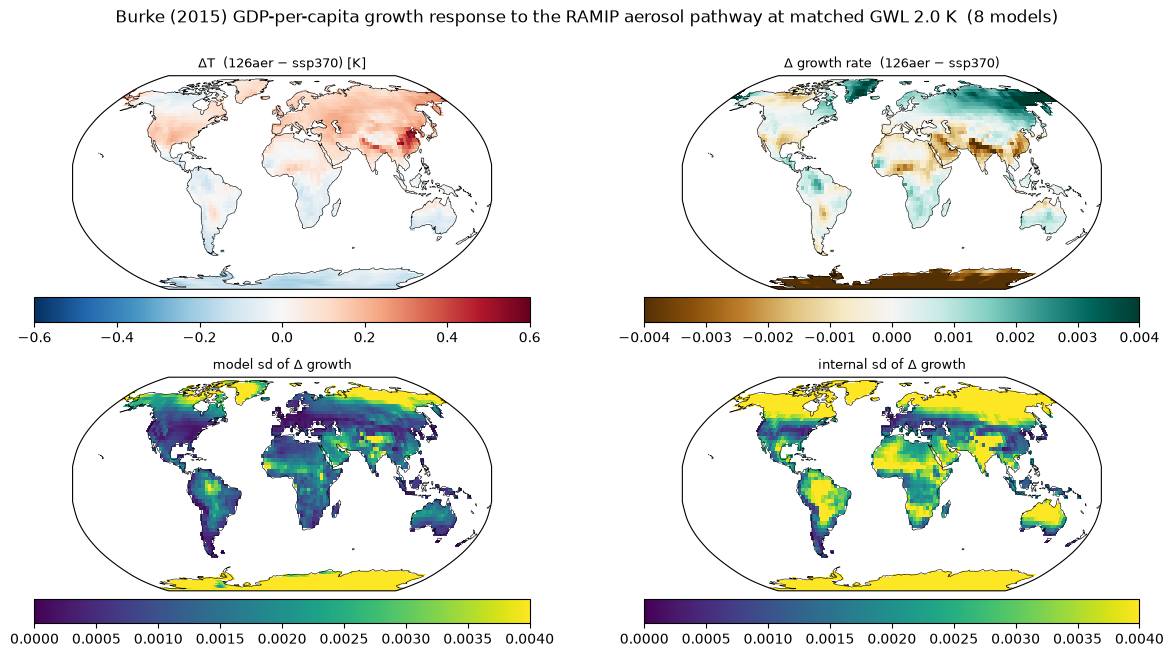

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(13, 6.5),
                        subplot_kw={'projection': ccrs.Robinson()})
panels = [(imp.dt.mean(('run', 'model')), 'ΔT  (126aer − ssp370) [K]', 'RdBu_r', 0.6),
          (sig, 'Δ growth rate  (126aer − ssp370)', 'BrBG', 0.004),
          (np.sqrt(v_mod), 'model sd of Δ growth', 'viridis', None),
          (np.sqrt(v_int), 'internal sd of Δ growth', 'viridis', None)]
for ax, (fld, title, cmap, lim) in zip(axs.flat, panels):
    kw = dict(vmin=-lim, vmax=lim) if lim else dict(vmin=0, vmax=0.004)
    im = ax.pcolormesh(fld.lon, fld.lat, fld.where(land), cmap=cmap,
                       transform=ccrs.PlateCarree(), **kw)
    ax.coastlines(lw=0.4)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.03, shrink=0.75)
fig.suptitle(f'Burke (2015) GDP-per-capita growth response to the RAMIP aerosol pathway '
             f'at matched GWL {GWL} K  ({len(MODELS)} models)', y=1.0)
fig.tight_layout()
fig.savefig(out_dir + f'ramip_impacts_burke_gwl{GWL}.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + f'ramip_impacts_burke_gwl{GWL}.png')

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ramip_impacts_burke_regions_gwl2.0.png


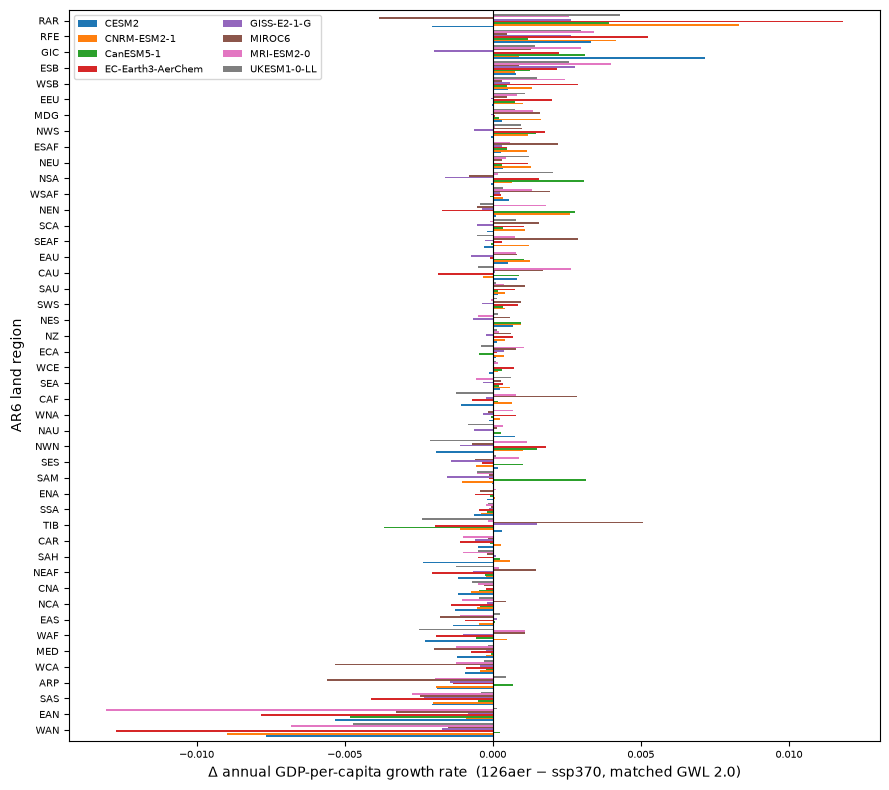

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
tab.drop(columns='multi-model mean').plot.barh(ax=ax, width=0.85, legend=True)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Δ annual GDP-per-capita growth rate  (126aer − ssp370, matched GWL 2.0)')
ax.set_ylabel('AR6 land region')
ax.legend(fontsize=7, ncol=2)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig(out_dir + f'ramip_impacts_burke_regions_gwl{GWL}.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + f'ramip_impacts_burke_regions_gwl{GWL}.png')